## Setup and Data Loading

In [7]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from linearmodels.panel import PanelOLS
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = [12, 8]
plt.rcParams['font.size'] = 12

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [8]:
# Load the dataset from the URL
url = "https://raw.githubusercontent.com/LOST-STATS/LOST-STATS.github.io/master/Model_Estimation/Data/Event_Study_DiD/bacon_example.csv"
df = pd.read_csv(url)

# Display basic information about the dataset
print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())
print("\nFirst few rows:")
df.head(10)

Dataset Shape: (1617, 10)

Column Names:
['stfips', 'year', '_nfd', 'post', 'asmrs', 'pcinc', 'asmrh', 'cases', 'weight', 'copop']

First few rows:


,stfips,year,_nfd,post,asmrs,pcinc,asmrh,cases,weight,copop
0,1,1964,1971.0,0,35.639885,12406.178537,5.007341,0.012312,1715156.0,1.715156e+06
1,1,1965,1971.0,0,41.543755,13070.206738,4.425367,0.010419,1715156.0,1.725186e+06
2,1,1966,1971.0,0,34.252335,13526.663217,4.874819,0.009900,1715156.0,1.735219e+06
3,1,1967,1971.0,0,34.465023,13918.189823,5.362014,0.009975,1715156.0,1.745250e+06
4,1,1968,1971.0,0,40.440105,14684.808682,4.643759,0.012401,1715156.0,1.755283e+06
5,1,1969,1971.0,0,42.490120,15638.876270,5.296976,0.015007,1715156.0,1.765316e+06
6,1,1970,1971.0,0,44.239075,16222.948376,4.716939,0.019703,1715156.0,1.787363e+06
7,1,1971,1971.0,1,49.914665,16875.429944,4.992504,0.022737,1715156.0,1.809412e+06
8,1,1972,1971.0,1,47.203133,17976.755117,5.187023,0.023556,1715156.0,1.831191e+06
9,1,1973,1971.0,1,41.033073,18808.246556,5.085546,0.025032,1715156.0,1.853536e+06


In [9]:
# Check data types and missing values
print("Data Types:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum())
print("\nBasic Statistics:")
df.describe()

Data Types:
stfips      int64
year        int64
_nfd      float64
post        int64
asmrs     float64
pcinc     float64
asmrh     float64
cases     float64
weight    float64
copop     float64
dtype: object

Missing Values:
stfips      0
year        0
_nfd      429
post        0
asmrs       0
pcinc       0
asmrh       0
cases       0
weight      0
copop       0
dtype: int64

Basic Statistics:


,stfips,year,_nfd,post,asmrs,pcinc,asmrh,cases,weight,copop
count,1617.000000,1617.00000,1188.000000,1617.000000,1617.000000,1617.000000,1617.000000,1617.000000,1.617000e+03,1.617000e+03
mean,29.795918,1980.00000,1973.583333,0.684601,52.166413,26080.967473,3.439058,0.024491,1.959531e+06,2.365343e+06
std,15.376316,9.52485,3.539969,0.464818,19.621876,6472.084916,1.901716,0.012091,2.032263e+06,2.494629e+06
min,1.000000,1964.00000,1969.000000,0.000000,7.477235,10274.976602,0.000000,0.003131,1.621688e+05,1.621688e+05
25%,18.000000,1972.00000,1971.000000,0.000000,40.237625,21462.046505,2.166024,0.015990,4.862876e+05,6.084960e+05
50%,30.000000,1980.00000,1973.000000,1.000000,48.842182,25783.268441,3.207187,0.023150,1.407318e+06,1.642584e+06
75%,42.000000,1988.00000,1974.250000,1.000000,60.035744,30008.420700,4.356279,0.031429,2.298065e+06,2.798542e+06
max,56.000000,1996.00000,1985.000000,1.000000,185.970886,48822.390731,19.134295,0.088966,9.028069e+06,1.603824e+07


In [10]:
# Examine the treatment structure
print("Unique treatment years (_nfd - treatment timing):")
print(sorted(df['_nfd'].unique()))
print("\nNumber of units (states):")
print(df['stfips'].nunique())
print("\nTime period range:")
print(f"From {df['year'].min()} to {df['year'].max()}")

Unique treatment years (_nfd - treatment timing):
[np.float64(1969.0), np.float64(1971.0), np.float64(1973.0), np.float64(nan), np.float64(1970.0), np.float64(1972.0), np.float64(1974.0), np.float64(1975.0), np.float64(1976.0), np.float64(1977.0), np.float64(1980.0), np.float64(1984.0), np.float64(1985.0)]

Number of units (states):
49

Time period range:
From 1964 to 1996


---

## Part a) Two-Way Fixed Effects (TWFE) Regression

The TWFE model is specified as:

$$Y_{it} = \alpha_i + \gamma_t + \beta \cdot D_{it} + X_{it}'\delta + \epsilon_{it}$$

Where:
- $\alpha_i$ = unit fixed effects
- $\gamma_t$ = time fixed effects  
- $D_{it}$ = treatment indicator (post × treated)
- $X_{it}$ = control variables

In [11]:
# Create the treatment indicators
df['_treated'] = (df['_nfd'] > 0).astype(int)
df['post'] = ((df['_nfd'] > 0) & (df['year'] >= df['_nfd'])).astype(int)

# Create the treatment indicator (interaction of post and treated)
df['treated_post'] = df['post'] * df['_treated']

# Verify the treatment indicator
print("Treatment indicator distribution:")
print(df.groupby(['_treated', 'post'])['treated_post'].mean())

Treatment indicator distribution:
_treated  post
0         0       0.0
1         0       0.0
          1       1.0
Name: treated_post, dtype: float64


In [12]:
# Prepare data for Panel OLS
# Set up multi-index for panel data
df_panel = df.set_index(['stfips', 'year'])

# Define the model formula
# Y = asmrs (outcome)
# Treatment = treated_post (post-treatment indicator)
# Controls = pcinc, asmrh, cases

y = df_panel['asmrs']
X = df_panel[['treated_post', 'pcinc', 'asmrh', 'cases']]
X = sm.add_constant(X)

print("Dependent variable (Y): asmrs")
print("Treatment variable: treated_post")
print("Control variables: pcinc, asmrh, cases")

Dependent variable (Y): asmrs
Treatment variable: treated_post
Control variables: pcinc, asmrh, cases


In [13]:
# Estimate TWFE model using PanelOLS
# Entity effects = unit fixed effects
# Time effects = time fixed effects

twfe_model = PanelOLS(
    dependent=df_panel['asmrs'],
    exog=df_panel[['treated_post', 'pcinc', 'asmrh', 'cases']],
    entity_effects=True,
    time_effects=True
)

# Fit with clustered standard errors at the state level
twfe_results = twfe_model.fit(cov_type='clustered', cluster_entity=True)

print("="*80)
print("TWO-WAY FIXED EFFECTS (TWFE) REGRESSION RESULTS")
print("="*80)
print(twfe_results)

TWO-WAY FIXED EFFECTS (TWFE) REGRESSION RESULTS
                          PanelOLS Estimation Summary                           
Dep. Variable:                  asmrs   R-squared:                        0.0346
Estimator:                   PanelOLS   R-squared (Between):             -1.4258
No. Observations:                1617   R-squared (Within):               0.2235
Date:                Wed, Dec 03 2025   R-squared (Overall):             -1.3323
Time:                        10:49:26   Log-likelihood                   -6107.4
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      13.727
Entities:                          49   P-value                           0.0000
Avg Obs:                       33.000   Distribution:                  F(4,1532)
Min Obs:                       33.000                                           
Max Obs:                       33.000   F-statistic (robust):

In [14]:
# Create a summary table for TWFE results
twfe_summary = pd.DataFrame({
    'Coefficient': twfe_results.params,
    'Std. Error': twfe_results.std_errors,
    't-statistic': twfe_results.tstats,
    'p-value': twfe_results.pvalues,
    'CI Lower (95%)': twfe_results.params - 1.96 * twfe_results.std_errors,
    'CI Upper (95%)': twfe_results.params + 1.96 * twfe_results.std_errors
})

print("\n" + "="*80)
print("TWFE COEFFICIENT SUMMARY TABLE")
print("="*80)
print(twfe_summary.round(4))

# Save the TWFE coefficient for later comparison
twfe_coef = twfe_results.params['treated_post']
twfe_se = twfe_results.std_errors['treated_post']
print(f"\n*** TWFE Treatment Effect: {twfe_coef:.4f} (SE: {twfe_se:.4f}) ***")


TWFE COEFFICIENT SUMMARY TABLE
              Coefficient  Std. Error  t-statistic  p-value  CI Lower (95%)  \
treated_post      -2.5160      2.2955      -1.0960   0.2732         -7.0152   
pcinc             -0.0011      0.0004      -3.0776   0.0021         -0.0018   
asmrh              1.1846      0.5797       2.0435   0.0412          0.0484   
cases           -178.5179    138.7244      -1.2869   0.1983       -450.4178   

              CI Upper (95%)  
treated_post          1.9833  
pcinc                -0.0004  
asmrh                 2.3208  
cases                93.3820  

*** TWFE Treatment Effect: -2.5160 (SE: 2.2955) ***


### Interpretation of TWFE Results

The TWFE coefficient on `treated_post` represents the average treatment effect of the policy intervention on age-standardized mortality rates (asmrs), controlling for:
- Unit-specific time-invariant characteristics (state fixed effects)
- Common time trends (year fixed effects)
- Time-varying covariates (pcinc, asmrh, cases)

**Caution:** In settings with staggered treatment adoption, the TWFE estimator may be biased due to "negative weighting" issues where already-treated units serve as controls.

---

## Part b) Cleaning for Event-Study

### Step 1: Create the Relative Time Variable

Event time is defined as: $\text{event\_time} = \text{year} - \text{treatment\_year}$

In [15]:
# Create a copy for event study analysis
df_es = df.copy()

# Identify the treatment year for each unit
# _nfd contains the treatment timing (0 for never-treated, positive year for treated)
df_es['treatment_year'] = df_es['_nfd']

# Create relative time (event time)
# For never-treated units (_nfd = 0), we'll handle them separately
df_es['event_time'] = np.where(
    df_es['treatment_year'] > 0,
    df_es['year'] - df_es['treatment_year'],
    np.nan  # Never-treated units get NaN initially
)

print("Relative time variable created!")
print("\nSample of data with event time:")
df_es[['stfips', 'year', 'treatment_year', 'event_time', 'asmrs']].head(20)

Relative time variable created!

Sample of data with event time:


,stfips,year,treatment_year,event_time,asmrs
0,1,1964,1971.0,-7.0,35.639885
1,1,1965,1971.0,-6.0,41.543755
2,1,1966,1971.0,-5.0,34.252335
3,1,1967,1971.0,-4.0,34.465023
4,1,1968,1971.0,-3.0,40.440105
5,1,1969,1971.0,-2.0,42.490120
6,1,1970,1971.0,-1.0,44.239075
7,1,1971,1971.0,0.0,49.914665
8,1,1972,1971.0,1.0,47.203133
9,1,1973,1971.0,2.0,41.033073


### Step 2: Frequency Table of Event Time

In [16]:
# Create frequency table for event time (excluding never-treated)
event_time_freq = df_es[df_es['event_time'].notna()]['event_time'].value_counts().sort_index()

print("="*60)
print("FREQUENCY TABLE OF EVENT TIME (RELATIVE TIME)")
print("="*60)

# Create a nice summary table
freq_table = pd.DataFrame({
    'Event Time': event_time_freq.index.astype(int),
    'Frequency': event_time_freq.values,
    'Percentage': (event_time_freq.values / event_time_freq.sum() * 100).round(2)
})
freq_table['Cumulative %'] = freq_table['Percentage'].cumsum().round(2)

print(freq_table.to_string(index=False))

print(f"\nTotal observations with event time: {event_time_freq.sum()}")
print(f"Never-treated observations: {df_es['event_time'].isna().sum()}")
print(f"Event time range: {int(event_time_freq.index.min())} to {int(event_time_freq.index.max())}")

FREQUENCY TABLE OF EVENT TIME (RELATIVE TIME)
 Event Time  Frequency  Percentage  Cumulative %
        -21          1        0.08          0.08
        -20          2        0.17          0.25
        -19          2        0.17          0.42
        -18          2        0.17          0.59
        -17          2        0.17          0.76
        -16          3        0.25          1.01
        -15          3        0.25          1.26
        -14          3        0.25          1.51
        -13          6        0.51          2.02
        -12          7        0.59          2.61
        -11          9        0.76          3.37
        -10         12        1.01          4.38
         -9         22        1.85          6.23
         -8         25        2.10          8.33
         -7         32        2.69         11.02
         -6         34        2.86         13.88
         -5         36        3.03         16.91
         -4         36        3.03         19.94
         -3         36 

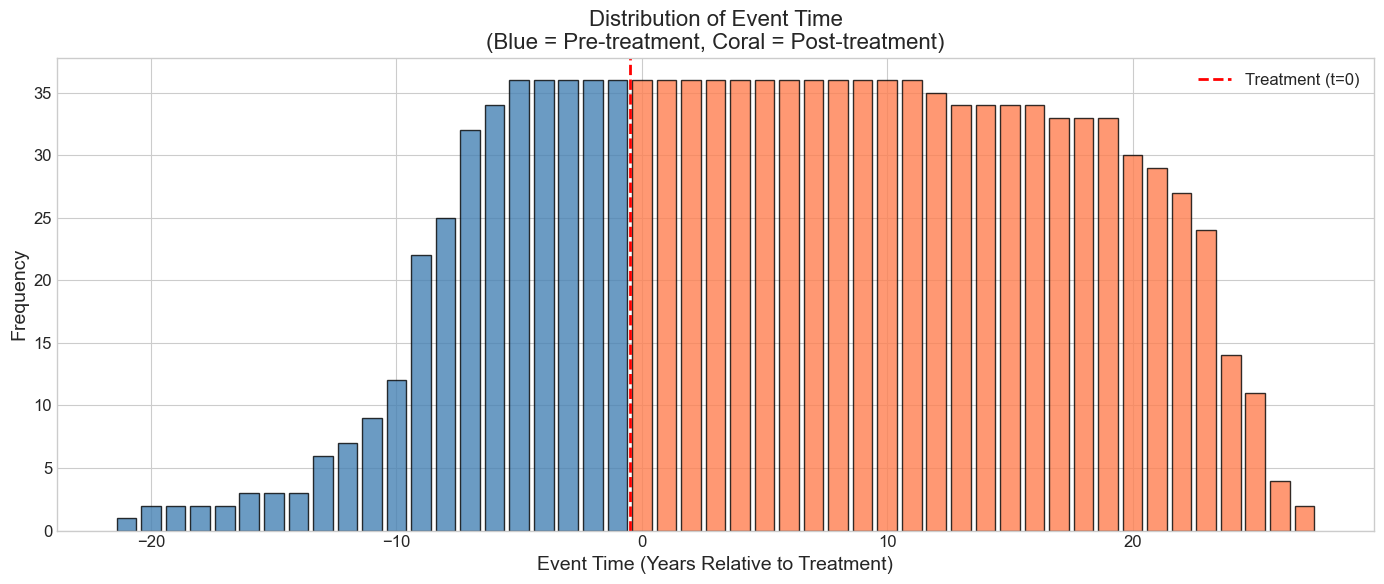


Figure saved to: ../output/event_time_distribution.png


In [17]:
# Visualize the distribution of event times
fig, ax = plt.subplots(figsize=(14, 6))

colors = ['steelblue' if x < 0 else 'coral' for x in event_time_freq.index]
bars = ax.bar(event_time_freq.index, event_time_freq.values, color=colors, edgecolor='black', alpha=0.8)

ax.axvline(x=-0.5, color='red', linestyle='--', linewidth=2, label='Treatment (t=0)')
ax.set_xlabel('Event Time (Years Relative to Treatment)', fontsize=14)
ax.set_ylabel('Frequency', fontsize=14)
ax.set_title('Distribution of Event Time\n(Blue = Pre-treatment, Coral = Post-treatment)', fontsize=16)
ax.legend(fontsize=12)

plt.tight_layout()
plt.savefig('../output/event_time_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nFigure saved to: ../output/event_time_distribution.png")

### Step 3: Choose Reasonable Bounds for Grouping Extreme Event Times

In [18]:
# Analyze the distribution to choose bounds
print("="*60)
print("ANALYSIS FOR CHOOSING EVENT TIME BOUNDS")
print("="*60)

# Check percentiles
event_times = df_es[df_es['event_time'].notna()]['event_time']
print("\nPercentiles of Event Time:")
for p in [5, 10, 25, 50, 75, 90, 95]:
    print(f"  {p}th percentile: {np.percentile(event_times, p):.0f}")

print("\nFrequency at extreme values:")
print(f"  Event time <= -10: {(event_times <= -10).sum()} obs ({(event_times <= -10).sum()/len(event_times)*100:.1f}%)")
print(f"  Event time >= 10: {(event_times >= 10).sum()} obs ({(event_times >= 10).sum()/len(event_times)*100:.1f}%)")

print("\nRecommended bounds: -10 to 10")
print("This captures the core of the distribution while grouping sparse tails.")

ANALYSIS FOR CHOOSING EVENT TIME BOUNDS

Percentiles of Event Time:
  5th percentile: -9
  10th percentile: -7
  25th percentile: -2
  50th percentile: 6
  75th percentile: 15
  90th percentile: 20
  95th percentile: 22

Frequency at extreme values:
  Event time <= -10: 52 obs (4.4%)
  Event time >= 10: 483 obs (40.7%)

Recommended bounds: -10 to 10
This captures the core of the distribution while grouping sparse tails.


In [19]:
# Set the bounds for binning
LOWER_BOUND = -10
UPPER_BOUND = 10

# Create binned event time
df_es['event_time_binned'] = df_es['event_time'].copy()
df_es.loc[df_es['event_time'] < LOWER_BOUND, 'event_time_binned'] = LOWER_BOUND
df_es.loc[df_es['event_time'] > UPPER_BOUND, 'event_time_binned'] = UPPER_BOUND

print(f"Event time binned to range [{LOWER_BOUND}, {UPPER_BOUND}]")
print("\nBinned event time distribution:")
print(df_es[df_es['event_time_binned'].notna()]['event_time_binned'].value_counts().sort_index())

Event time binned to range [-10, 10]

Binned event time distribution:
event_time_binned
-10.0     52
-9.0      22
-8.0      25
-7.0      32
-6.0      34
-5.0      36
-4.0      36
-3.0      36
-2.0      36
-1.0      36
 0.0      36
 1.0      36
 2.0      36
 3.0      36
 4.0      36
 5.0      36
 6.0      36
 7.0      36
 8.0      36
 9.0      36
 10.0    483
Name: count, dtype: int64


### Step 4: Why Do We Group Distant Event Times Together?

**Answer:**

We group very distant event times (e.g., event time < -10 or > 10) together for several important reasons:

1. **Statistical Power**: Extreme event times typically have very few observations, leading to imprecise estimates with large standard errors. Grouping them improves precision.

2. **Avoiding Multicollinearity**: With many event-time dummies and few observations per period at the extremes, we risk near-perfect collinearity issues.

3. **Focus on Relevant Time Window**: The most policy-relevant dynamics typically occur close to the treatment date. Effects at very distant periods are often less informative for understanding the treatment mechanism.

4. **Composition Effects**: At extreme lags/leads, only certain cohorts contribute to estimation. This can introduce composition bias if cohorts differ systematically.

5. **Practical Interpretation**: It's difficult to meaningfully interpret effects 20+ years before or after treatment, as other confounding factors likely dominate.

### Step 5: Create Relative-Time Dummy Variables

In [20]:
# Create dummy variables for each event time
# We exclude event_time = -1 as the reference category (normalization)

# First, handle never-treated units by assigning them a special category
# For event study, we typically either drop them or include them as always-control
df_es_treated = df_es[df_es['treatment_year'] > 0].copy()

# Create dummies for each event time (excluding -1 as reference)
event_times_for_dummies = range(LOWER_BOUND, UPPER_BOUND + 1)
reference_period = -1

for t in event_times_for_dummies:
    if t != reference_period:
        col_name = f'event_time_{t}' if t < 0 else f'event_time_p{t}'
        col_name = col_name.replace('-', 'm')  # Replace minus sign
        df_es_treated[col_name] = (df_es_treated['event_time_binned'] == t).astype(int)

# Show the dummy variables created
dummy_cols = [col for col in df_es_treated.columns if 'event_time_m' in col or 'event_time_p' in col]
print(f"Created {len(dummy_cols)} event-time dummy variables")
print(f"Reference category: event_time = {reference_period}")
print("\nDummy variables created:")
print(dummy_cols)

Created 20 event-time dummy variables
Reference category: event_time = -1

Dummy variables created:
['event_time_m10', 'event_time_m9', 'event_time_m8', 'event_time_m7', 'event_time_m6', 'event_time_m5', 'event_time_m4', 'event_time_m3', 'event_time_m2', 'event_time_p0', 'event_time_p1', 'event_time_p2', 'event_time_p3', 'event_time_p4', 'event_time_p5', 'event_time_p6', 'event_time_p7', 'event_time_p8', 'event_time_p9', 'event_time_p10']


In [21]:
# Verify the dummies sum correctly
print("\nVerification - Sum of dummies per observation (should be 0 or 1):")
dummy_sum = df_es_treated[dummy_cols].sum(axis=1)
print(dummy_sum.value_counts())

# The observations with sum=0 are those at the reference period (-1)
print(f"\nObservations at reference period (t=-1): {(dummy_sum == 0).sum()}")


Verification - Sum of dummies per observation (should be 0 or 1):
1    1152
0      36
Name: count, dtype: int64

Observations at reference period (t=-1): 36


---

## Part c) Event-Study Estimation

The event-study model is:

$$Y_{it} = \alpha_i + \gamma_t + \sum_{k \neq -1} \beta_k \cdot \mathbf{1}[K_{it} = k] + X_{it}'\delta + \epsilon_{it}$$

Where $K_{it}$ is the event time for unit $i$ at time $t$, and $k = -1$ is the reference period.

In [22]:
# Prepare data for event study regression
df_es_panel = df_es_treated.set_index(['stfips', 'year'])

# Define independent variables: event time dummies + controls
exog_vars = dummy_cols + ['pcinc', 'asmrh', 'cases']

# Check for any missing values
print("Missing values in exogenous variables:")
print(df_es_panel[exog_vars].isnull().sum())

# Drop any rows with missing values
df_es_panel_clean = df_es_panel.dropna(subset=exog_vars + ['asmrs'])
print(f"\nObservations for estimation: {len(df_es_panel_clean)}")

Missing values in exogenous variables:
event_time_m10    0
event_time_m9     0
event_time_m8     0
event_time_m7     0
event_time_m6     0
event_time_m5     0
event_time_m4     0
event_time_m3     0
event_time_m2     0
event_time_p0     0
event_time_p1     0
event_time_p2     0
event_time_p3     0
event_time_p4     0
event_time_p5     0
event_time_p6     0
event_time_p7     0
event_time_p8     0
event_time_p9     0
event_time_p10    0
pcinc             0
asmrh             0
cases             0
dtype: int64

Observations for estimation: 1188


In [23]:
# Estimate Event-Study model with TWFE
event_study_model = PanelOLS(
    dependent=df_es_panel_clean['asmrs'],
    exog=df_es_panel_clean[exog_vars],
    entity_effects=True,
    time_effects=True
)

# Fit with clustered standard errors
event_study_results = event_study_model.fit(cov_type='clustered', cluster_entity=True)

print("="*80)
print("EVENT-STUDY REGRESSION RESULTS")
print("="*80)
print(event_study_results.summary)

EVENT-STUDY REGRESSION RESULTS
                          PanelOLS Estimation Summary                           
Dep. Variable:                  asmrs   R-squared:                        0.0303
Estimator:                   PanelOLS   R-squared (Between):             -0.8896
No. Observations:                1188   R-squared (Within):               0.2953
Date:                Wed, Dec 03 2025   R-squared (Overall):             -0.8233
Time:                        10:49:28   Log-likelihood                   -4473.5
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      1.4891
Entities:                          36   P-value                           0.0645
Avg Obs:                       33.000   Distribution:                 F(23,1097)
Min Obs:                       33.000                                           
Max Obs:                       33.000   F-statistic (robust):             5.18

In [24]:
# Extract and store coefficient estimates and standard errors for event-time dummies
es_coefs = []

for col in dummy_cols:
    # Parse the event time from column name
    if 'event_time_m' in col:
        t = -int(col.replace('event_time_m', ''))
    else:
        t = int(col.replace('event_time_p', ''))
    
    coef = event_study_results.params[col]
    se = event_study_results.std_errors[col]
    
    es_coefs.append({
        'event_time': t,
        'coefficient': coef,
        'std_error': se,
        'ci_lower': coef - 1.96 * se,
        'ci_upper': coef + 1.96 * se,
        't_stat': coef / se,
        'p_value': 2 * (1 - stats.norm.cdf(abs(coef / se)))
    })

# Add the reference period (t = -1)
es_coefs.append({
    'event_time': -1,
    'coefficient': 0,
    'std_error': 0,
    'ci_lower': 0,
    'ci_upper': 0,
    't_stat': np.nan,
    'p_value': np.nan
})

# Create DataFrame and sort by event time
es_results_df = pd.DataFrame(es_coefs).sort_values('event_time').reset_index(drop=True)

print("="*80)
print("EVENT-STUDY COEFFICIENTS TABLE")
print("="*80)
print(es_results_df.round(4).to_string(index=False))

EVENT-STUDY COEFFICIENTS TABLE
 event_time  coefficient  std_error  ci_lower  ci_upper  t_stat  p_value
        -10      -6.1488     7.7346  -21.3086    9.0110 -0.7950   0.4266
         -9      -7.3180     6.1283  -19.3295    4.6934 -1.1941   0.2324
         -8      -4.4308     5.9697  -16.1315    7.2699 -0.7422   0.4580
         -7      -2.7089     5.8312  -14.1381    8.7203 -0.4645   0.6423
         -6      -2.1368     4.5232  -11.0022    6.7287 -0.4724   0.6366
         -5      -3.7881     3.5524  -10.7508    3.1746 -1.0663   0.2863
         -4      -0.6193     2.8465   -6.1984    4.9597 -0.2176   0.8278
         -3      -3.1396     2.9817   -8.9837    2.7044 -1.0530   0.2923
         -2      -0.6546     2.4499   -5.4564    4.1472 -0.2672   0.7893
         -1       0.0000     0.0000    0.0000    0.0000     NaN      NaN
          0       1.2099     2.8089   -4.2956    6.7153  0.4307   0.6667
          1      -0.3126     3.4554   -7.0852    6.4601 -0.0905   0.9279
          2       0.

In [25]:
# Save the event-study results for later comparison
es_results_df.to_csv('../output/event_study_coefficients.csv', index=False)
print("Event-study coefficients saved to: ../output/event_study_coefficients.csv")

Event-study coefficients saved to: ../output/event_study_coefficients.csv


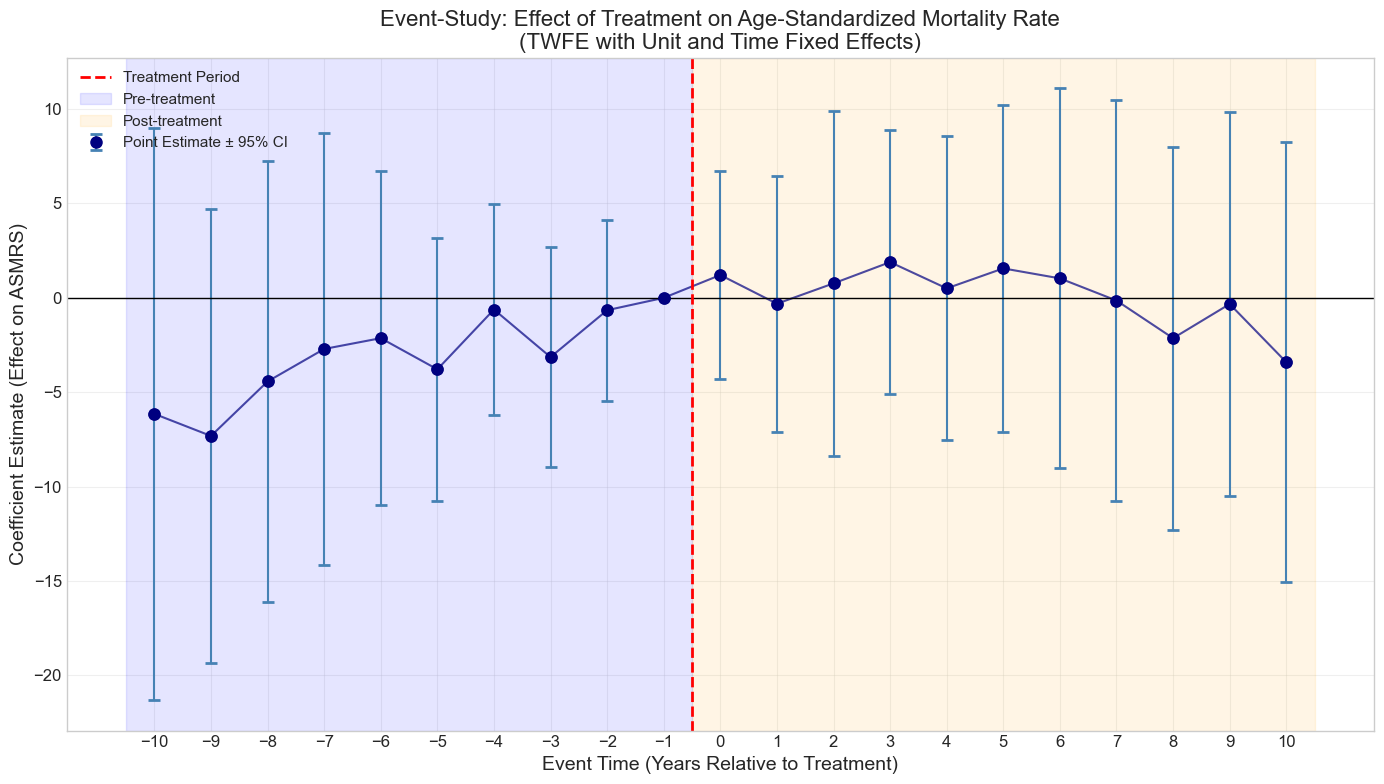


Figure saved to: ../output/event_study_plot.png


In [26]:
# Create the Event-Study Plot
fig, ax = plt.subplots(figsize=(14, 8))

# Plot the coefficients with confidence intervals
ax.errorbar(
    es_results_df['event_time'],
    es_results_df['coefficient'],
    yerr=1.96 * es_results_df['std_error'],
    fmt='o',
    markersize=8,
    capsize=4,
    capthick=2,
    color='navy',
    ecolor='steelblue',
    label='Point Estimate ± 95% CI'
)

# Add connecting line
ax.plot(es_results_df['event_time'], es_results_df['coefficient'], 
        'o-', color='navy', alpha=0.7, markersize=8)

# Add reference lines
ax.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax.axvline(x=-0.5, color='red', linestyle='--', linewidth=2, label='Treatment Period')

# Highlight pre-treatment period
ax.axvspan(LOWER_BOUND - 0.5, -0.5, alpha=0.1, color='blue', label='Pre-treatment')
ax.axvspan(-0.5, UPPER_BOUND + 0.5, alpha=0.1, color='orange', label='Post-treatment')

# Labels and formatting
ax.set_xlabel('Event Time (Years Relative to Treatment)', fontsize=14)
ax.set_ylabel('Coefficient Estimate (Effect on ASMRS)', fontsize=14)
ax.set_title('Event-Study: Effect of Treatment on Age-Standardized Mortality Rate\n(TWFE with Unit and Time Fixed Effects)', fontsize=16)
ax.legend(loc='upper left', fontsize=11)
ax.set_xticks(range(LOWER_BOUND, UPPER_BOUND + 1))

# Add grid
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../output/event_study_plot.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nFigure saved to: ../output/event_study_plot.png")

### Interpretation of Event-Study Results

The event-study plot shows the dynamic effects of the treatment relative to the period just before treatment (t = -1, normalized to zero).

**Key observations:**

1. **Pre-trends**: Coefficients before treatment (t < 0) should ideally be close to zero and statistically insignificant if the parallel trends assumption holds.

2. **Treatment effects**: Coefficients after treatment (t ≥ 0) show how the outcome evolves following the intervention.

3. **Dynamic patterns**: The event-study reveals whether effects are immediate, gradual, or temporary.

**Important caveat**: In settings with staggered treatment adoption, these TWFE-based event-study estimates may be biased. Later units may be compared to already-treated units rather than never-treated units, potentially leading to negative weights on some comparisons.

---

## Summary

### Key Results

1. **TWFE Estimate**: The average treatment effect estimated via TWFE regression.

2. **Event-Study**: Dynamic treatment effects showing the trajectory of outcomes before and after treatment.

### Files Saved
- `../output/event_time_distribution.png`: Distribution of event times
- `../output/event_study_plot.png`: Event-study coefficient plot
- `../output/event_study_coefficients.csv`: Coefficient estimates table

In [27]:
# Final summary statistics
print("="*80)
print("SUMMARY OF QUESTION 1 RESULTS")
print("="*80)
print(f"\nTWFE Treatment Effect: {twfe_coef:.4f} (SE: {twfe_se:.4f})")
print(f"\nEvent-Study Coefficients Range:")
print(f"  Pre-treatment (t<0): {es_results_df[es_results_df['event_time'] < 0]['coefficient'].min():.4f} to {es_results_df[es_results_df['event_time'] < 0]['coefficient'].max():.4f}")
print(f"  Post-treatment (t>=0): {es_results_df[es_results_df['event_time'] >= 0]['coefficient'].min():.4f} to {es_results_df[es_results_df['event_time'] >= 0]['coefficient'].max():.4f}")
print("\nOutput files generated:")
print("  - event_time_distribution.png")
print("  - event_study_plot.png")
print("  - event_study_coefficients.csv")

SUMMARY OF QUESTION 1 RESULTS

TWFE Treatment Effect: -2.5160 (SE: 2.2955)

Event-Study Coefficients Range:
  Pre-treatment (t<0): -7.3180 to 0.0000
  Post-treatment (t>=0): -3.4091 to 1.8931

Output files generated:
  - event_time_distribution.png
  - event_study_plot.png
  - event_study_coefficients.csv
